In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(BuenColors)
library(EnsDb.Hsapiens.v86)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: ensembldb

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,

In [2]:
output_folder='~/0_perturb_multiome_manuscript_figures/'

In [3]:
JAN_028_combined=readRDS('~/github_reproducibility/merged_seurat_object_step2_all_reps.RDS')

In [5]:
`%notin%` <- Negate(`%in%`)

In [6]:
library(dplyr)

JAN_028_combined@meta.data=JAN_028_combined@meta.data %>%
  mutate(rep_info = as.numeric(gsub("rep","",gsub("(.+)_.*", "\\1", row.names(JAN_028_combined@meta.data)))))


In [8]:
JAN_028_combined_filtered=JAN_028_combined[,row.names(JAN_028_combined@meta.data%>%
dplyr::filter(rep_info %notin% c(11,15)))]

In [9]:
JAN_028_combined_filtered=JAN_028_combined_filtered[,row.names(JAN_028_combined_filtered@meta.data %>%
dplyr::filter(nCount_ATAC >0))]

In [10]:
JAN_028_combined_filtered@meta.data=JAN_028_combined_filtered@meta.data %>%
mutate(timepoint = ifelse(rep_info %in% c(1,2,3,4),"Day 7",
                         ifelse(rep_info %in% c(5,6,7,8), "Day 9",
                               ifelse(rep_info %in% c(9,10,12),"Day 11","Day 14"))))

JAN_028_combined_filtered@meta.data$timepoint = factor(JAN_028_combined_filtered@meta.data$timepoint,
                                                         levels = c("Day 7","Day 9", "Day 11", "Day 14"))

In [11]:
# Define colors from the BuenColors package
bueno_colors <- c('Day 14' = jdb_color_map(c("MEP")),
                  'Day 11' = jdb_color_map(c("CMP")),
                  'Day 9' = jdb_color_map(c("LMPP")), 
                  'Day 7' = jdb_color_map(c("CD4")))




# Define colors from the BuenColors package
bueno_colors <- c('Day 14' = jdb_color_map(c("MEP")),
                  'Day 11' = jdb_color_map(c("CMP")),
                  'Day 9' = jdb_color_map(c("CLP")), 
                  'Day 7' = jdb_color_map(c("CD4")))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."
Warning message:
"The `fun.y` argument of `stat_summary()` is deprecated as of ggplot2 3.3.0.
ℹ Please use the `fun` argument instead."
Warning message:
"Removed 19 rows containing non-finite outside the scale range
(`stat_ydensity()`)."
Warning message:
"Removed 19 rows containing non-finite outside the scale range
(`stat_summary()`)."


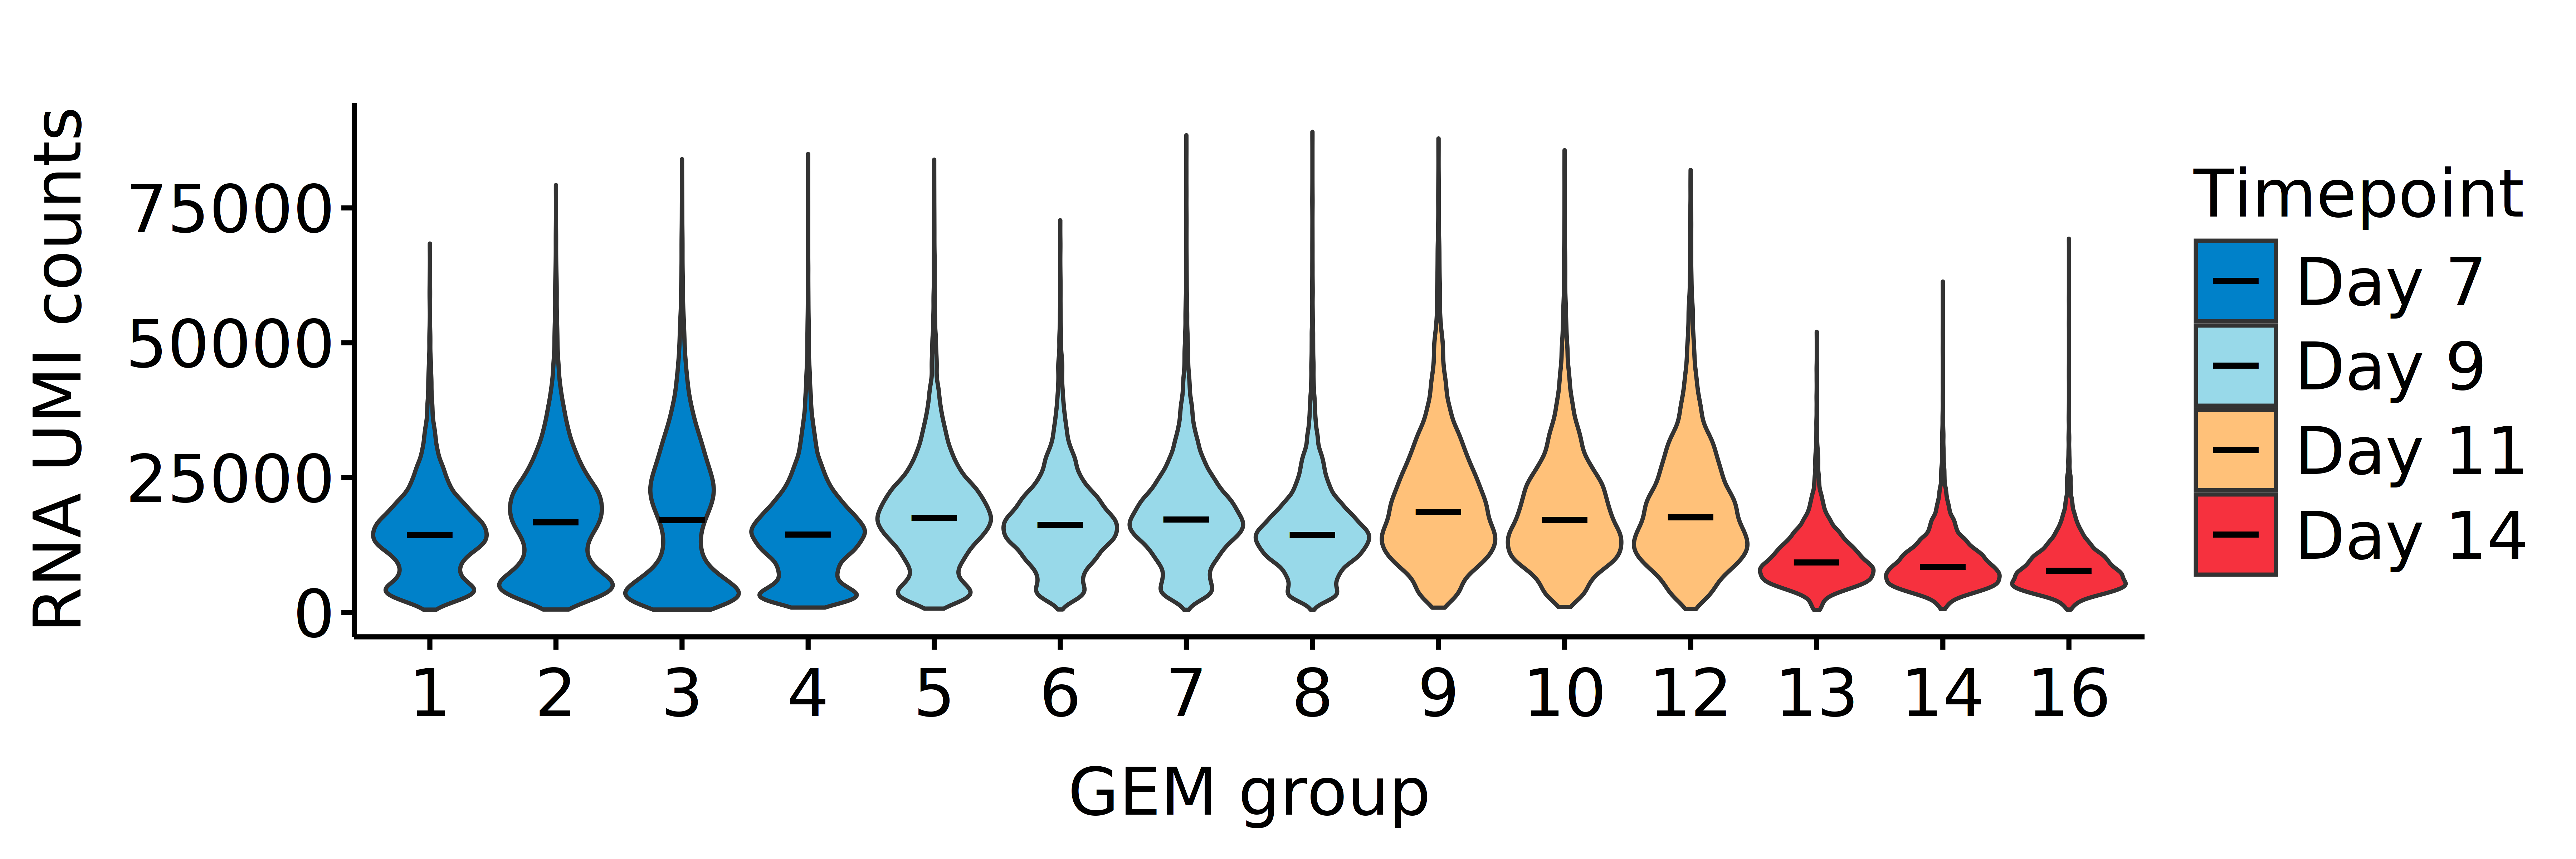

In [12]:
figure_name='JAN_028_RNA_UMI_counts.pdf'
width=12
height=4
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 600)

library(ggplot2)
VlnPlot(JAN_028_combined_filtered,c("nCount_RNA"),group.by='rep_info',pt.size=0)+ylim(0,90000)+aes(fill=JAN_028_combined_filtered$timepoint)+
  scale_fill_manual(values = bueno_colors) +
  labs( title='',x = 'GEM group', y = 'RNA UMI counts') +
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title.x = element_text(size = 22,margin = unit(c(6, 0, 0, 0), "mm")),
          axis.title.y = element_text(size = 22,margin = unit(c(0, 4, 0, 0), "mm")),
      axis.ticks = element_line(size = .6),
      axis.ticks.length=unit(0.06,"inch"),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0, size = 22,color='black'),
    axis.text.y = element_text(size = 22,color='black'),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black",size = .6),
    strip.text = element_text(size = 16),
      legend.key.size = unit(1, 'cm'),
      legend.text=element_text(size=22),
      legend.title=element_text(size=22),
    strip.background = element_blank()
  )+ guides(fill=guide_legend(title="Timepoint"))+
stat_summary(fun.y = median, geom='point', size = 10,  colour = "black", shape = 95)

#ggsave(paste(output_folder,figure_name,sep=""),dpi = 600, width = width, height = height)



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
"Removed 8 rows containing non-finite outside the scale range
(`stat_ydensity()`)."
Warning message:
"Removed 8 rows containing non-finite outside the scale range
(`stat_summary()`)."


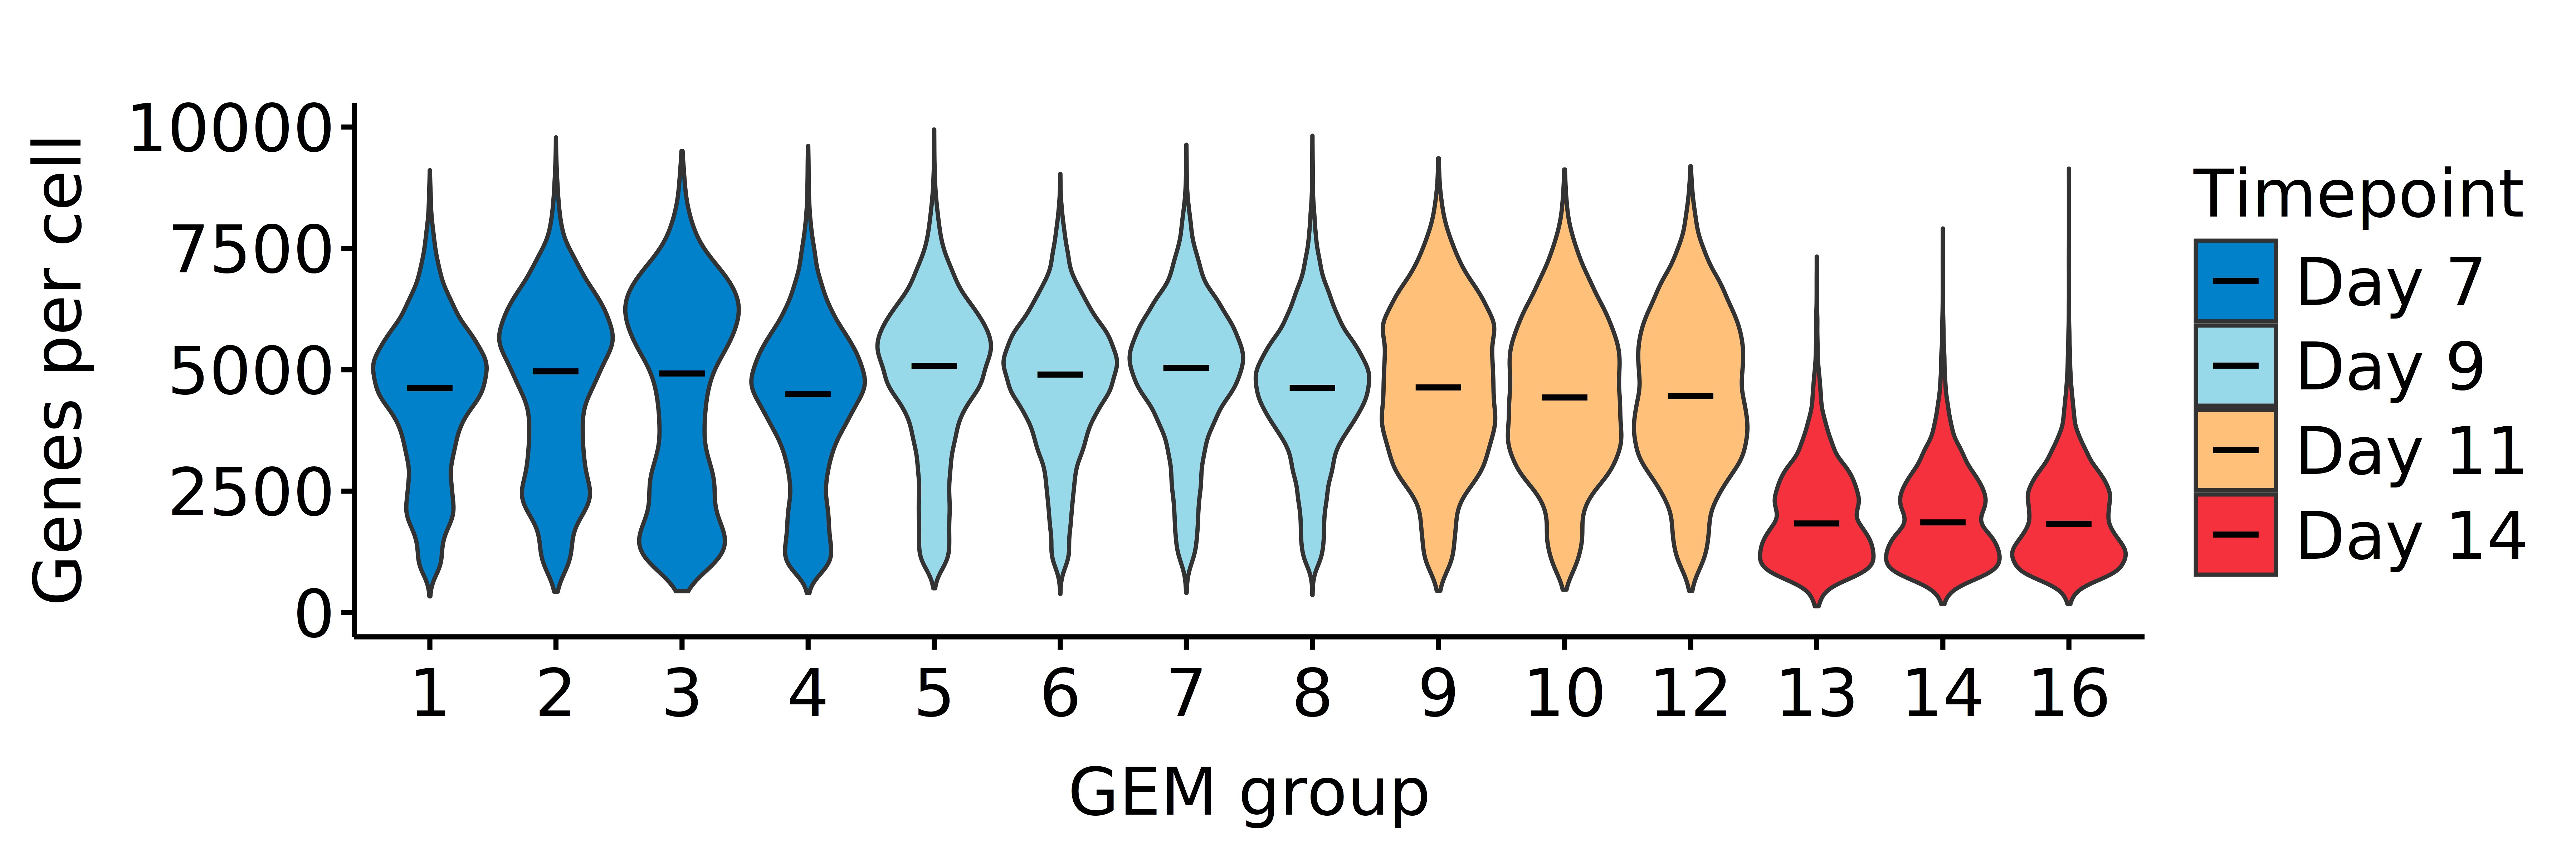

In [13]:
figure_name='JAN_028_RNA_nFeature.pdf'
width=12
height=4
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 600)

library(ggplot2)
VlnPlot(JAN_028_combined_filtered,c("nFeature_RNA"),group.by='rep_info',pt.size=0)+ylim(0,10000)+aes(fill=JAN_028_combined_filtered$timepoint)+
  scale_fill_manual(values = bueno_colors) +
  labs( title='',x = 'GEM group', y = 'Genes per cell') +
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title.x = element_text(size = 22,margin = unit(c(6, 0, 0, 0), "mm")),
          axis.title.y = element_text(size = 22,margin = unit(c(0, 4, 0, 0), "mm")),
      axis.ticks = element_line(size = .6),
      axis.ticks.length=unit(0.06,"inch"),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0, size = 22,color='black'),
    axis.text.y = element_text(size = 22,color='black'),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black",size = .6),
    strip.text = element_text(size = 16),
      legend.key.size = unit(1, 'cm'),
      legend.text=element_text(size=22),
      legend.title=element_text(size=22),
    strip.background = element_blank()
  )+ guides(fill=guide_legend(title="Timepoint"))+
stat_summary(fun.y = median, geom='point', size = 10,  colour = "black", shape = 95)

#ggsave(paste(output_folder,figure_name,sep=""),dpi = 600, width = width, height = height)



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
"Removed 732 rows containing non-finite outside the scale range
(`stat_ydensity()`)."
Warning message:
"Removed 732 rows containing non-finite outside the scale range
(`stat_summary()`)."


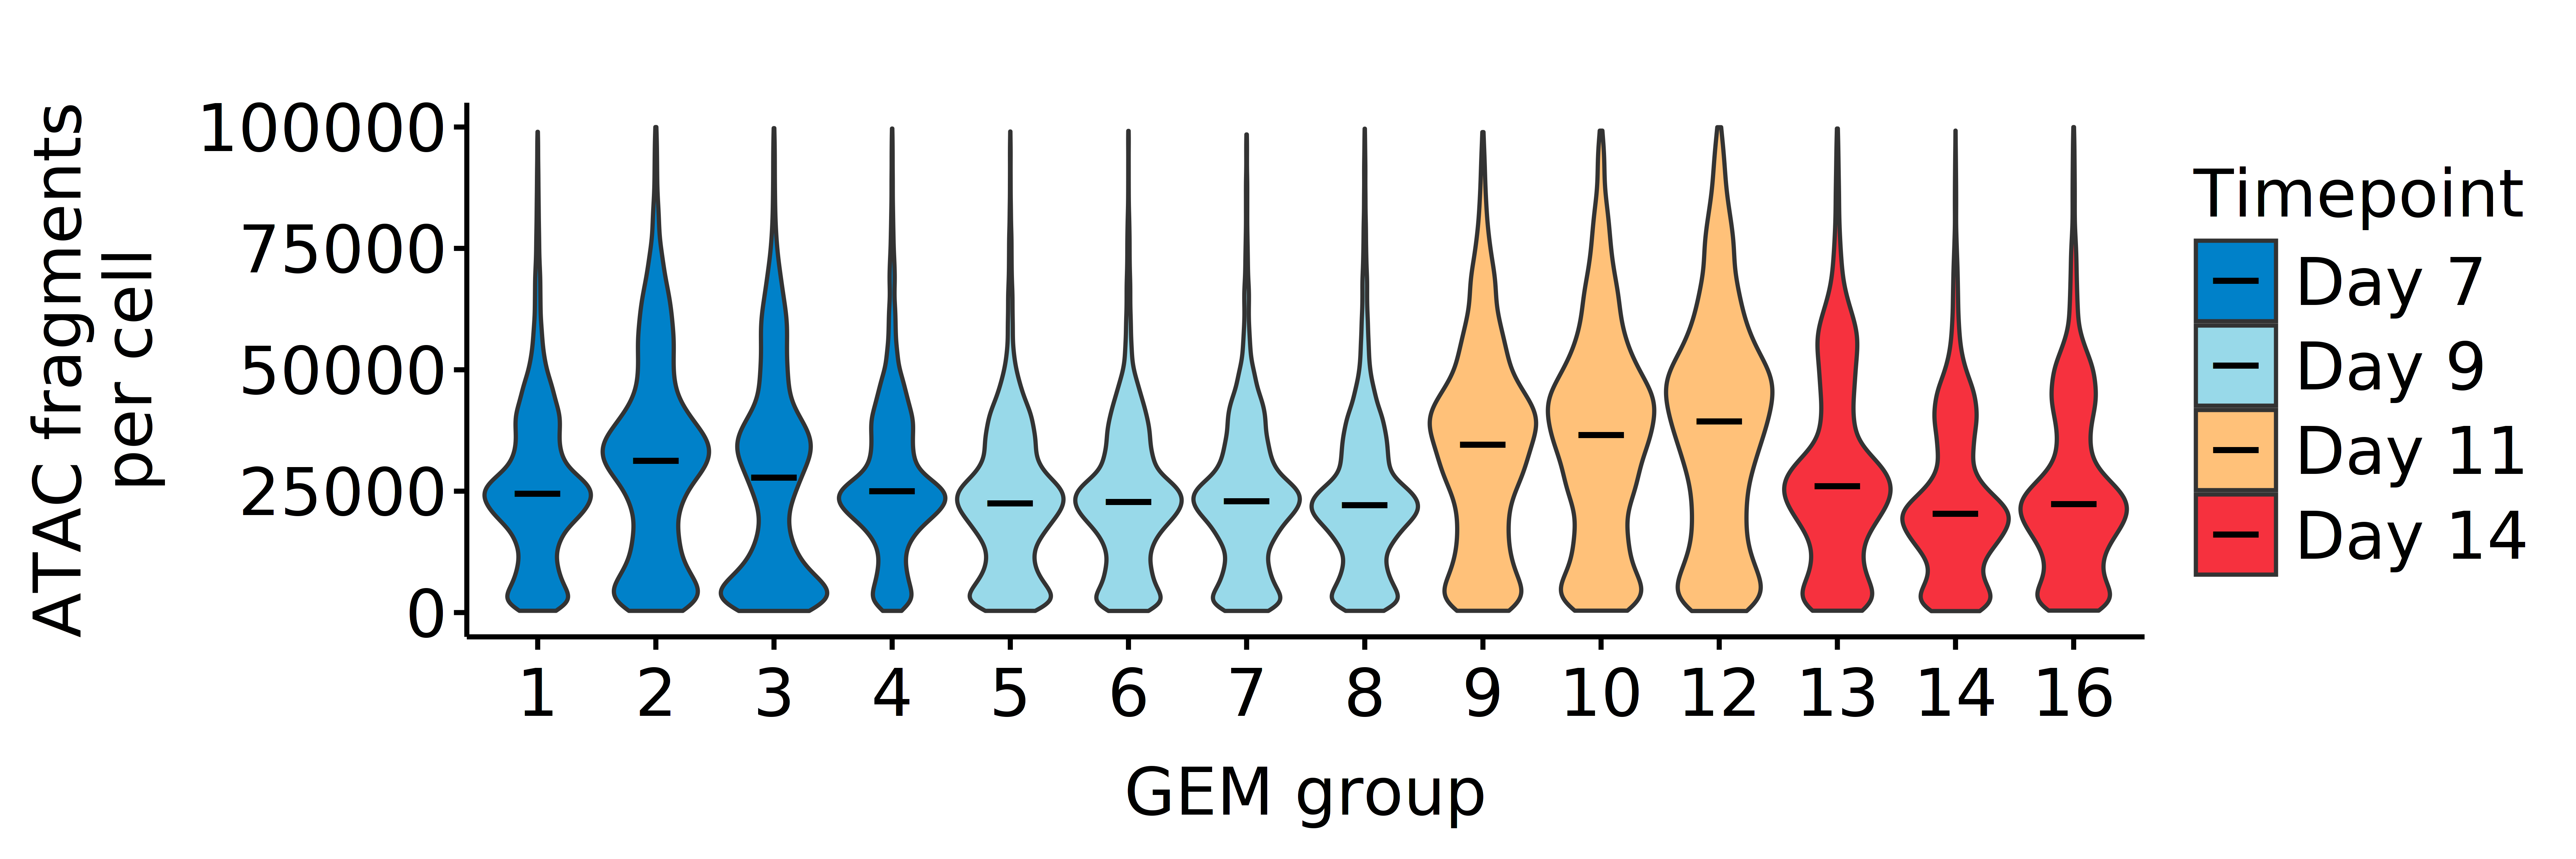

In [14]:
figure_name='JAN_028_nCount_atac.pdf'
width=12
height=4
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 600)

library(ggplot2)
VlnPlot(JAN_028_combined_filtered,c("nCount_atac"),group.by='rep_info',pt.size=0)+ylim(0,100000)+aes(fill=JAN_028_combined_filtered$timepoint)+
  scale_fill_manual(values = bueno_colors) +
  labs( title='',x = 'GEM group', y = 'ATAC fragments\nper cell') +
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title.x = element_text(size = 22,margin = unit(c(6, 0, 0, 0), "mm")),
          axis.title.y = element_text(size = 22,margin = unit(c(0, 4, 0, 0), "mm")),
      axis.ticks = element_line(size = .6),
      axis.ticks.length=unit(0.06,"inch"),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0, size = 22,color='black'),
    axis.text.y = element_text(size = 22,color='black'),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black",size = .6),
    strip.text = element_text(size = 16),
      legend.key.size = unit(1, 'cm'),
      legend.text=element_text(size=22),
      legend.title=element_text(size=22),
    strip.background = element_blank()
  )+ guides(fill=guide_legend(title="Timepoint"))+
stat_summary(fun.y = median, geom='point', size = 10,  colour = "black", shape = 95)

#ggsave(paste(output_folder,figure_name,sep=""),dpi = 600, width = width, height = height)



Same plots but relative to the number of reads per GEM group. Import "per_barcode_metrics.csv" produced by Cellranger

In [15]:
library(dplyr)

replicate_data_list <- list()

for (i in 1:16) {
    print(i)
  file_path <- paste0("~/JAN_028/rep", i, "_per_barcode_metrics.csv")
  
  replicate_metrics <- read.table(file_path, header = TRUE, sep = ',')
  
  replicate_metrics$barcode <- paste0("rep", i, "_", replicate_metrics$barcode)
  
  filtered_replicate_metrics <- replicate_metrics %>%
    dplyr::filter(barcode %in% colnames(JAN_028_combined_filtered))
  
  replicate_data_list[[i]] <- filtered_replicate_metrics
}



[1] 1
[1] 2
[1] 3
[1] 4
[1] 5
[1] 6
[1] 7
[1] 8
[1] 9
[1] 10
[1] 11
[1] 12
[1] 13
[1] 14
[1] 15
[1] 16


In [16]:
combined_data <- bind_rows(replicate_data_list)



In [17]:
combined_data_merged=merge(JAN_028_combined_filtered@meta.data,combined_data,by.x='row.names',
     by.y='barcode')

In [18]:
combined_data_merged=combined_data_merged[match(colnames(JAN_028_combined_filtered), combined_data_merged$Row.names), ]



In [19]:
row.names(combined_data_merged)=combined_data_merged$Row.names

In [20]:
JAN_028_combined_filtered@meta.data=combined_data_merged

In [21]:
JAN_028_combined_filtered@meta.data=JAN_028_combined_filtered@meta.data %>%
mutate(UMI_per_read = nCount_RNA/gex_raw_reads)

In [22]:
JAN_028_combined_filtered@meta.data=JAN_028_combined_filtered@meta.data %>%
mutate(ATAC_fragment_per_read = nCount_atac/atac_raw_reads)

Numbers for the main text:

In [23]:
mean(JAN_028_combined_filtered@meta.data$nCount_RNA)

[1] 15970.07

In [24]:
mean(JAN_028_combined_filtered@meta.data$nFeature_RNA)

[1] 4129.029

In [25]:
mean(JAN_028_combined_filtered@meta.data$nCount_atac)

[1] 27743.6

In [26]:
mean(JAN_028_combined_filtered@meta.data$nFeature_atac)

[1] 10802.81

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


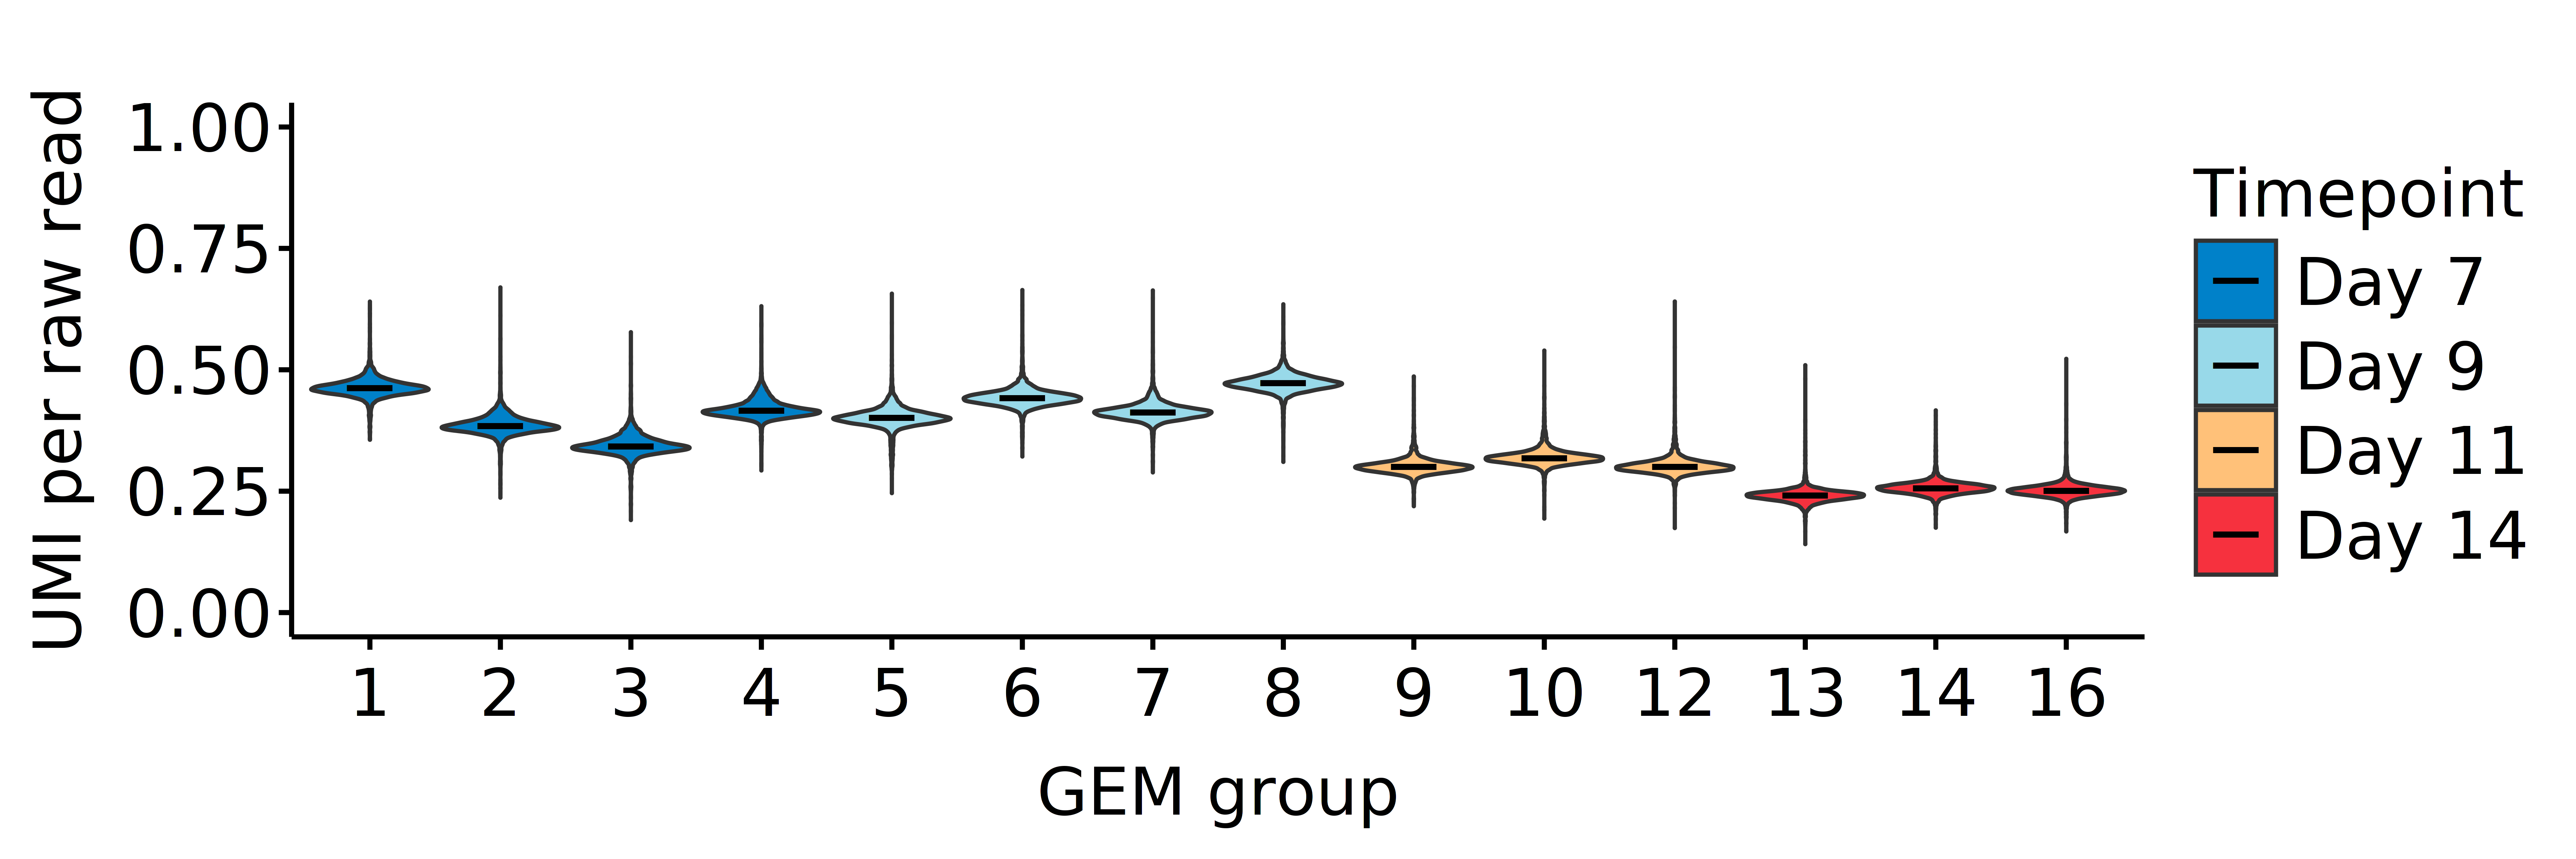

In [27]:
figure_name='JAN_028_nCount_RNA_by_reads.pdf'
width=12
height=4
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 600)

library(ggplot2)
VlnPlot(JAN_028_combined_filtered,c("UMI_per_read"),group.by='rep_info',pt.size=0)+ylim(0,1)+aes(fill=JAN_028_combined_filtered$timepoint)+
  scale_fill_manual(values = bueno_colors) +
  labs( title='',x = 'GEM group', y = 'UMI per raw read') +
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title.x = element_text(size = 22,margin = unit(c(6, 0, 0, 0), "mm")),
          axis.title.y = element_text(size = 22,margin = unit(c(0, 4, 0, 0), "mm")),
      axis.ticks = element_line(size = .6),
      axis.ticks.length=unit(0.06,"inch"),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0, size = 22,color='black'),
    axis.text.y = element_text(size = 22,color='black'),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black",size = .6),
    strip.text = element_text(size = 16),
      legend.key.size = unit(1, 'cm'),
      legend.text=element_text(size=22),
      legend.title=element_text(size=22),
    strip.background = element_blank()
  )+ guides(fill=guide_legend(title="Timepoint"))+
stat_summary(fun.y = median, geom='point', size = 10,  colour = "black", shape = 95)

#ggsave(paste(output_folder,figure_name,sep=""),dpi = 600, width = width, height = height)



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
"Removed 2 rows containing non-finite outside the scale range
(`stat_ydensity()`)."
Warning message:
"Removed 2 rows containing non-finite outside the scale range
(`stat_summary()`)."


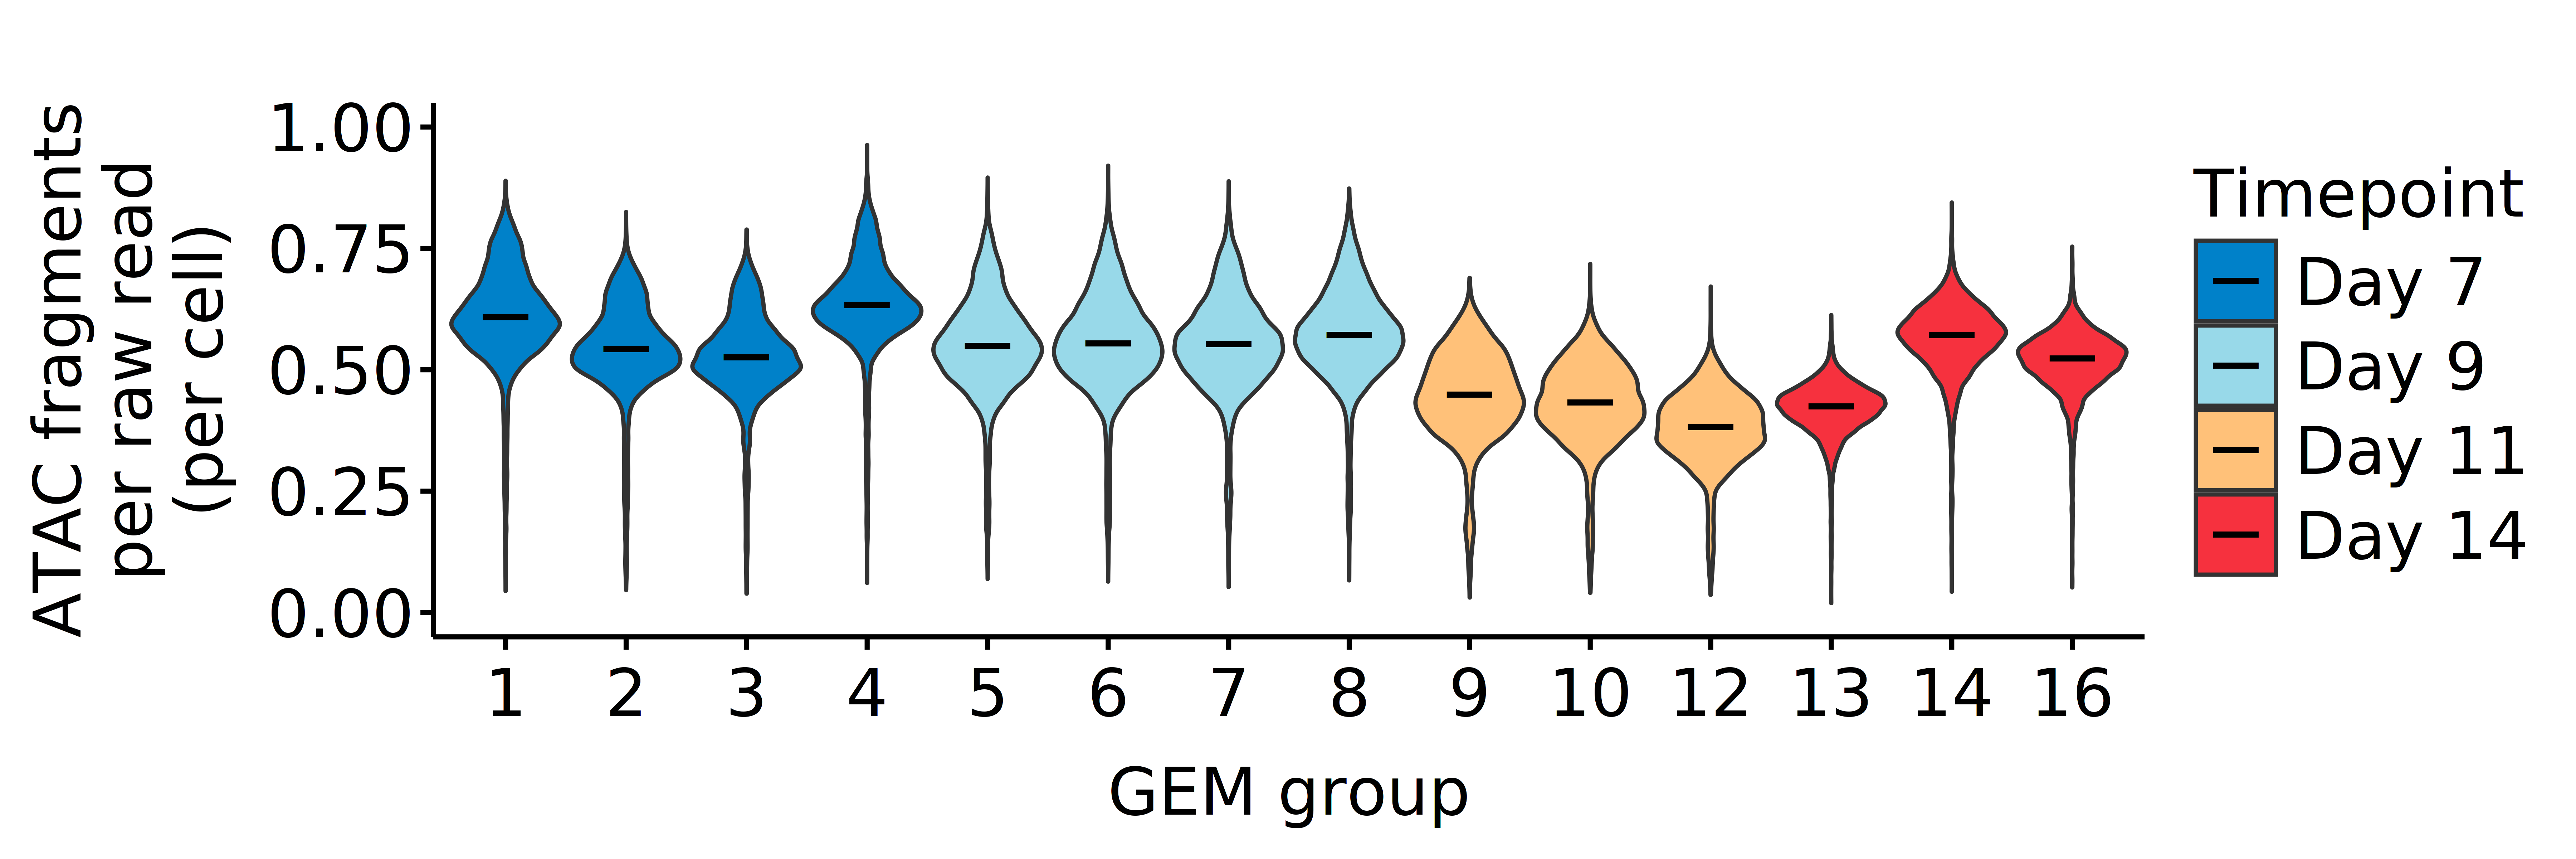

In [28]:
figure_name='JAN_028_nCount_atac_by_reads.pdf'
width=12
height=4
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 600)

library(ggplot2)
VlnPlot(JAN_028_combined_filtered,c("ATAC_fragment_per_read"),group.by='rep_info',pt.size=0)+ylim(0,1)+aes(fill=JAN_028_combined_filtered$timepoint)+
  scale_fill_manual(values = bueno_colors) +
  labs( title='',x = 'GEM group', y = 'ATAC fragments\nper raw read\n(per cell)') +
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title.x = element_text(size = 22,margin = unit(c(6, 0, 0, 0), "mm")),
          axis.title.y = element_text(size = 22,margin = unit(c(0, 4, 0, 0), "mm")),
      axis.ticks = element_line(size = .6),
      axis.ticks.length=unit(0.06,"inch"),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0, size = 22,color='black'),
    axis.text.y = element_text(size = 22,color='black'),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "black",size = .6),
    strip.text = element_text(size = 16),
      legend.key.size = unit(1, 'cm'),
      legend.text=element_text(size=22),
      legend.title=element_text(size=22),
    strip.background = element_blank()
  )+ guides(fill=guide_legend(title="Timepoint"))+
stat_summary(fun.y = median, geom='point', size = 10,  colour = "black", shape = 95)

#ggsave(paste(output_folder,figure_name,sep=""),dpi = 600, width = width, height = height)

